# Musical Signal Analysis Using Fourier Transform

This project analyzes the frequency content of musical signals using the Fourier Transform. By comparing the spectra of different instruments (violin and clarinet), the project demonstrates how timbre differences arise from variations in harmonic structure.

The analysis combines mathematical theory, signal processing, and data visualization to connect frequency-domain representations with perceptual sound characteristics.

## 1. Data Collection

Audio samples of a violin and clarinet playing the same note (A4, 440 Hz) are used for analysis.

Each recording is a time-domain waveform representing sound amplitude over time. Using a single sustained pitch allows for a controlled comparison of harmonic structure and timbre between the instruments.


In [17]:
from google.colab import files
files.upload()

Saving violin.wav to violin (2).wav
Saving clarinet.wav to clarinet (2).wav


{'violin (2).wav': b'ID3\x02\x00\x00\x00\x00\x10!TT2\x00\x00\x08\x000326 1\x00TEN\x00\x00\r\x00iTunes v4.2\x00COM\x00\x00h\x00engiTunNORM\x00 0000004D 00000000 000002E9 00000000 000000B6 00000000 000017D4 00000000 000000B6 00000000\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

## 2. Fourier Transform (FFT)

The audio signals are converted from the time domain to the frequency domain using the Fast Fourier Transform (FFT). This reveals the frequency components and harmonic structure of each instrument.

## Mathematical Background

The Discrete Fourier Transform (DFT) is defined as:

$$
X_k = \sum_{n=0}^{N-1} x_n \, e^{-2\pi i \frac{k n}{N}}
$$

where:

- $x_n$ is the time-domain signal  
- $X_k$ is the frequency-domain representation  
- $N$ is the number of samples


This transformation decomposes a signal into a sum of complex exponentials corresponding to different frequencies.


The Fast Fourier Transform (FFT) is an efficient algorithm for computing the DFT with time complexity $O(N \log N)$.

This transformation allows us to identify dominant frequencies and harmonic structure in musical signals.

In [18]:
import librosa

violin_signal, violin_sr = librosa.load("violin.wav", sr=None)
clarinet_signal, clarinet_sr = librosa.load("clarinet.wav", sr=None)

print("Loaded successfully")

Loaded successfully


In [19]:
import numpy as np

def compute_fft(signal, sample_rate):
    n = len(signal)

    fft_values = np.fft.rfft(signal)
    magnitudes = np.abs(fft_values)

    frequencies = np.fft.rfftfreq(n, d=1/sample_rate)

    return frequencies, magnitudes

violin_freqs, violin_mags = compute_fft(violin_signal, violin_sr)
clarinet_freqs, clarinet_mags = compute_fft(clarinet_signal, clarinet_sr)

In [20]:
violin_mags = violin_mags / np.max(violin_mags)
clarinet_mags = clarinet_mags / np.max(clarinet_mags)

The spectra are normalized so the comparison focuses on relative harmonic structure rather than differences in recording volume.

## 3. Frequency Spectrum Visualization

The frequency spectrum of each instrument is plotted. Peaks in the graph represent dominant frequencies and harmonics present in the sound.

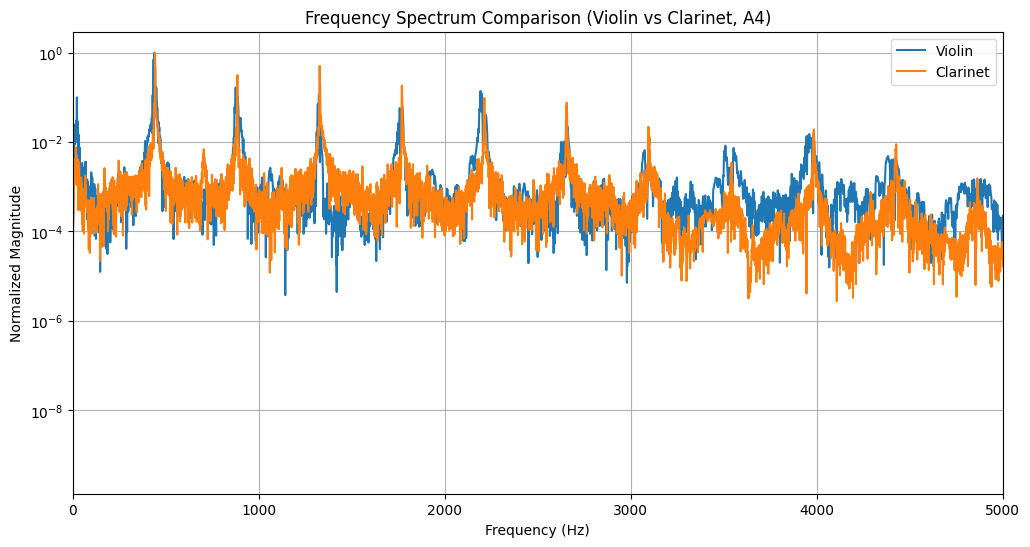

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(violin_freqs, violin_mags, label="Violin")
plt.plot(clarinet_freqs, clarinet_mags, label="Clarinet")

plt.xlim(0, 5000)  # focus on useful frequencies

plt.title("Frequency Spectrum Comparison (Violin vs Clarinet, A4)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude")

plt.yscale('log')

plt.legend()
plt.grid(True)

plt.show()



In [22]:
threshold = 0.001

violin_mags_clean = np.where(violin_mags > threshold, violin_mags, 0)
clarinet_mags_clean = np.where(clarinet_mags > threshold, clarinet_mags, 0)


## Frequency Spectrum Interpretation

The frequency spectrum shows clear peaks at the fundamental frequency (~440 Hz) and its harmonics (integer multiples of 440 Hz), consistent with the  structure described by the DFT.

From the graph, the violin exhibits stronger energy in higher-frequency harmonics compared to the clarinet. This is visible in the more pronounced peaks at higher frequencies (above ~2000 Hz), indicating that the violin contains more high-frequency content.

In contrast, the clarinet’s energy is more concentrated in the lower harmonics, with relatively weaker higher-frequency peaks, resulting in a more compact frequency distribution.

These differences reflect how each instrument distributes energy across harmonics:
- The violin spreads energy across a wider range of frequencies
- The clarinet concentrates energy in lower-frequency components

This explains the perceived timbre difference between the instruments, with the violin sounding brighter and the clarinet sounding warmer.

A threshold was applied to remove low-magnitude noise from the spectrum, allowing the dominant harmonic structure to be more clearly observed.

Overall, this demonstrates how the Fourier Transform maps a time-domain signal into its frequency-domain representation, where timbre differences emerge as variations in harmonic amplitude.

## 4. Noise Reduction and Signal Cleaning

Low-magnitude frequency components are removed using a threshold to highlight the dominant harmonic peaks. This reduces noise in the spectrum and makes the underlying harmonic structure easier to analyze without significantly affecting the perceived pitch or timbre.

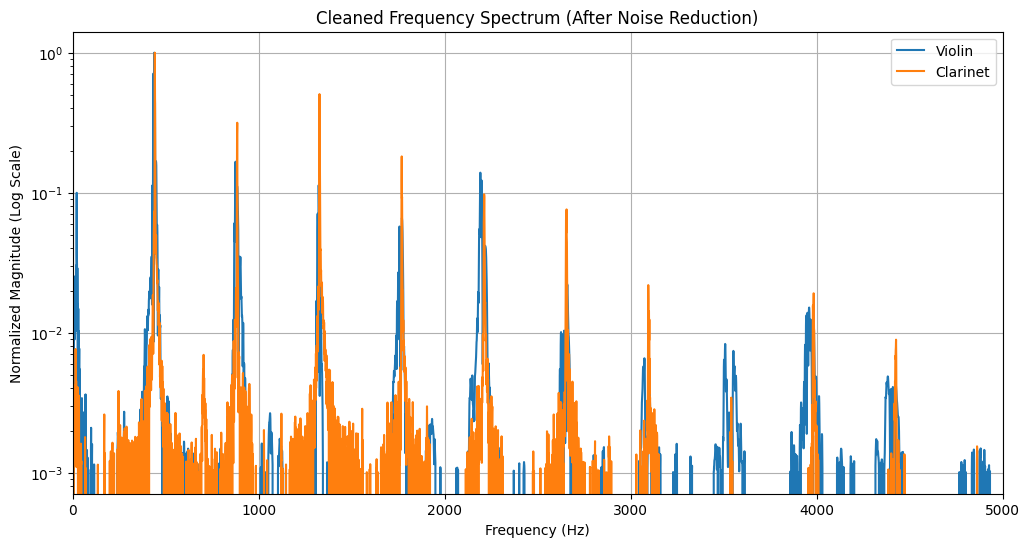

In [28]:
plt.figure(figsize=(12,6))

plt.plot(violin_freqs, violin_mags_clean, label="Violin")
plt.plot(clarinet_freqs, clarinet_mags_clean, label="Clarinet")

plt.xlim(0, 5000)

plt.title("Cleaned Frequency Spectrum (After Noise Reduction)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude (Log Scale)")

plt.yscale('log')

plt.legend()
plt.grid(True)

plt.show()

## 5. Harmonic Analysis

The strength of the first eight harmonics is extracted by identifying peaks near multiples of the fundamental frequency (440 Hz). This allows for a quantitative comparison of harmonic content between instruments.

In [24]:
import pandas as pd

fundamental = 440
num_harmonics = 8

def get_harmonic_strengths(frequencies, magnitudes, fundamental, num_harmonics, window=20):
    strengths = []

    for i in range(1, num_harmonics + 1):
        target_freq = fundamental * i

        mask = (frequencies >= target_freq - window) & (frequencies <= target_freq + window)

        if np.any(mask):
            strength = np.max(magnitudes[mask])
        else:
            strength = 0

        strengths.append(strength)

    strengths = np.array(strengths)
    strengths = strengths / np.max(strengths)

    return strengths

violin_harmonics = get_harmonic_strengths(
    violin_freqs, violin_mags, fundamental, num_harmonics
)

clarinet_harmonics = get_harmonic_strengths(
    clarinet_freqs, clarinet_mags, fundamental, num_harmonics
)

harmonic_numbers = np.arange(1, num_harmonics + 1)

harmonic_df = pd.DataFrame({
    "Harmonic": harmonic_numbers,
    "Frequency (Hz)": harmonic_numbers * fundamental,
    "Violin Strength": violin_harmonics,
    "Clarinet Strength": clarinet_harmonics
})

harmonic_df

,Harmonic,Frequency (Hz),Violin Strength,Clarinet Strength
0,1,440,1.000000,1.000000
1,2,880,0.166513,0.316150
2,3,1320,0.112950,0.506133
3,4,1760,0.066036,0.181693
4,5,2200,0.139051,0.097393
5,6,2640,0.022055,0.076006
6,7,3080,0.006570,0.021888
7,8,3520,0.008320,0.001966


### Harmonic Strength Comparison

A bar chart is used to compare the relative strength of harmonics between the violin and clarinet.

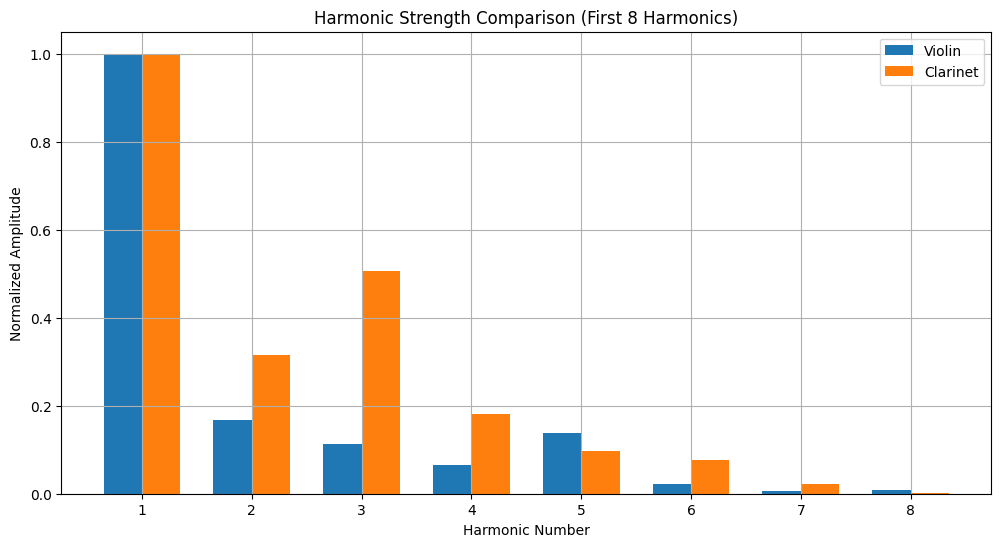

In [29]:
x = np.arange(len(harmonic_numbers))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, violin_harmonics, width, label="Violin")
plt.bar(x + width/2, clarinet_harmonics, width, label="Clarinet")

plt.xticks(x, harmonic_numbers)
plt.title("Harmonic Strength Comparison (First 8 Harmonics)")
plt.xlabel("Harmonic Number")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 6. Spectral Feature Analysis

Spectral features such as centroid and spread are calculated to summarize how frequency energy is distributed. These metrics help quantify differences in brightness and timbre.

In [26]:
def spectral_centroid(frequencies, magnitudes):
    return np.sum(frequencies * magnitudes) / np.sum(magnitudes)

def spectral_spread(frequencies, magnitudes):
    centroid = spectral_centroid(frequencies, magnitudes)
    return np.sqrt(np.sum(((frequencies - centroid) ** 2) * magnitudes) / np.sum(magnitudes))

violin_centroid = spectral_centroid(violin_freqs, violin_mags)
clarinet_centroid = spectral_centroid(clarinet_freqs, clarinet_mags)

violin_spread = spectral_spread(violin_freqs, violin_mags)
clarinet_spread = spectral_spread(clarinet_freqs, clarinet_mags)

feature_df = pd.DataFrame({
    "Instrument": ["Violin", "Clarinet"],
    "Spectral Centroid": [violin_centroid, clarinet_centroid],
    "Spectral Spread": [violin_spread, clarinet_spread],
    "Average Harmonic Strength": [
        np.mean(violin_harmonics),
        np.mean(clarinet_harmonics)
    ],
    "High Harmonic Strength (Harmonics 5-8)": [
        np.mean(violin_harmonics[4:]),
        np.mean(clarinet_harmonics[4:])
    ]
})

feature_df

,Instrument,Spectral Centroid,Spectral Spread,Average Harmonic Strength,High Harmonic Strength (Harmonics 5-8)
0,Violin,1863.541936,2371.585876,0.190187,0.043999
1,Clarinet,1672.042837,1826.214155,0.275153,0.049313


## 7. Interpretation of Results

The spectral centroid of the violin (1863 Hz) is higher than that of the clarinet (1672 Hz), indicating that the violin contains more high-frequency energy and is therefore perceived as brighter.

The spectral spread is also larger for the violin, meaning its sound energy is distributed across a wider range of frequencies. This contributes to a richer and more complex timbre.

In contrast, the clarinet has a lower spectral centroid and spread, indicating a more concentrated frequency distribution. This aligns with the clarinet’s characteristic warm and focused tone.

Interestingly, the clarinet has a higher average harmonic strength, suggesting that its harmonics are more pronounced overall. However, both instruments show relatively low high-harmonic strength (harmonics 5–8), indicating that most of the energy is concentrated in the lower harmonics.

Overall, this confirms that while both instruments produce the same fundamental pitch, their timbre differs due to how energy is distributed across harmonics and frequencies.

## Limitations and Extensions

This analysis uses a single sustained note for each instrument, which simplifies comparison but does not capture the full variability of a real musical performance.

Factors such as dynamics, articulation, vibrato, and recording conditions can significantly affect the frequency spectrum.

Additionally, the FFT assumes the signal is stationary over time, which is not always true for real music.

Future improvements could include:
- Time-frequency analysis (Short-Time Fourier Transform)
- Comparing multiple notes across different pitches
- Using machine learning to classify instruments based on spectral features

## 8. Conclusion

This project demonstrates how Fourier analysis can be used to quantify timbre in musical signals. By transforming audio from the time domain to the frequency domain, it becomes possible to identify harmonic structures and compare instruments objectively.

The results show that even when two instruments play the same note, differences in harmonic strength and frequency distribution lead to distinct sounds. This highlights the importance of higher-order harmonics in shaping timbre.

This approach can be extended to applications such as instrument classification, audio synthesis, and music information retrieval.